# Feature analysis: weather

## Question

---

How is weather related to demand, and which weather features do we actually need? Specifically:
1. are `temperature_c` and `perceived_temperature_c` redundant;
2. is the temperature–demand relationship linear (do trees need it);
3. how much does precipitation reduce demand, and is there a `weather × hour` interaction.

> **Data discipline.** Descriptive analysis on **train** only (val/test kept aside) — to understand the process.
> Feature and model selection happens on validation in [eda_and_modeling.ipynb](eda_and_modeling.ipynb); test stays untouched until the end.
> Source — `hourly_by_location.csv` (pipeline output).

## Setup

---

We read `hourly_by_location` and aggregate to the hourly level (weather is the same across locations within an hour), then take train.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PROCESSED = Path("../data/processed")
fd = pd.read_csv(DATA_PROCESSED / "hourly_by_location.csv", parse_dates=["datetime_hourly"])

WEATHER = ["conditions", "temperature_c", "perceived_temperature_c", "humidity", "windspeed_kmh"]
hourly = (fd.groupby("datetime_hourly")
          .agg(total=("total_rentals", "sum"), hour=("hour_of_day", "first"),
               **{w: (w, "first") for w in WEATHER})
          .reset_index())

ts = np.sort(hourly["datetime_hourly"].unique())
train = hourly[hourly["datetime_hourly"] < ts[int(len(ts) * 0.70)]]
print(f"train hours: {len(train)}")

train hours: 12165


## 1. Temperature collinearity

---

`temperature_c` and `perceived_temperature_c` are two measurements of the same thing. If they duplicate each other, one is redundant.

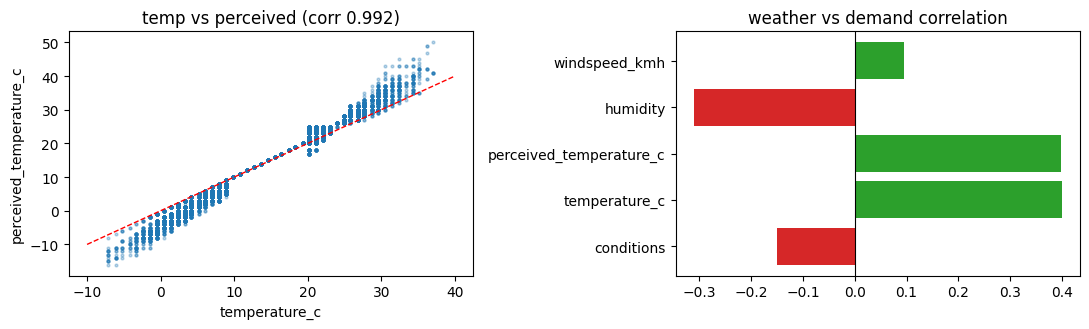

temp vs perceived: corr 0.9918,  |diff| <= 12.9 C  (mean -0.2)


In [2]:
corr = train["temperature_c"].corr(train["perceived_temperature_c"])
diff = train["perceived_temperature_c"] - train["temperature_c"]
wcorr = train[["total"] + WEATHER].corr()["total"].drop("total")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].scatter(train["temperature_c"], train["perceived_temperature_c"], s=4, alpha=0.3)
ax[0].plot([-10, 40], [-10, 40], "r--", lw=1)
ax[0].set_xlabel("temperature_c"); ax[0].set_ylabel("perceived_temperature_c")
ax[0].set_title(f"temp vs perceived (corr {corr:.3f})")
ax[1].barh(wcorr.index, wcorr.values, color=["#d62728" if v < 0 else "#2ca02c" for v in wcorr])
ax[1].axvline(0, color="black", lw=0.8); ax[1].set_title("weather vs demand correlation")
plt.tight_layout(); plt.show()

print(f"temp vs perceived: corr {corr:.4f},  |diff| <= {diff.abs().max():.1f} C  (mean {diff.mean():+.1f})")

### Observations

- `perceived_temperature_c` is almost identical to `temperature_c`: **corr 0.99**, the difference is on average zero (occasionally up to ~13°C), and the correlation with demand is the same (**0.40**). It looks redundant — but the decision is made by an experiment, not by correlation: ablation [#5](eda_and_modeling.ipynb) showed it **cannot** be dropped. The ~1% where the two differ (a wind/humidity correction) is used by the tree.
- Humidity is a clear negative (−0.31), wind almost zero (0.09), `conditions` a weak negative (−0.15).

## 2. Temperature → demand

---

Is the relationship linear, or is there nonlinearity (a peak at comfortable temperature, a drop in the heat)?

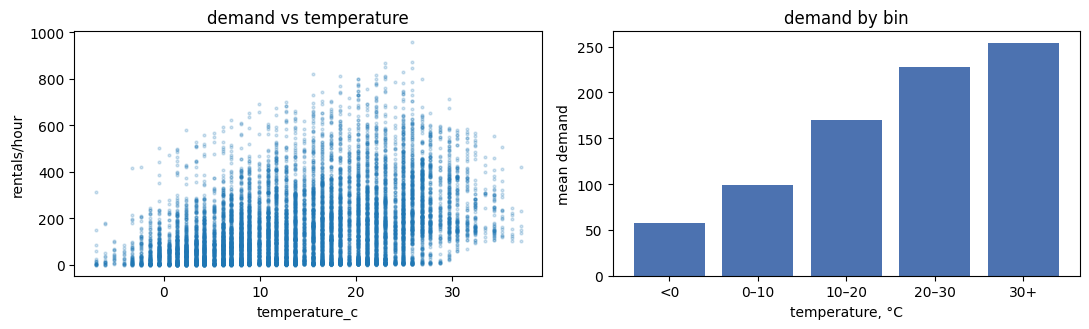

tbin
<0        57.0
0–10      99.0
10–20    170.0
20–30    228.0
30+      254.0


In [3]:
bins = [-100, 0, 10, 20, 30, 100]; labels = ["<0", "0–10", "10–20", "20–30", "30+"]
by_temp = (train.assign(tbin=pd.cut(train["temperature_c"], bins=bins, labels=labels))
           .groupby("tbin", observed=True)["total"].mean())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].scatter(train["temperature_c"], train["total"], s=4, alpha=0.2)
ax[0].set_xlabel("temperature_c"); ax[0].set_ylabel("rentals/hour"); ax[0].set_title("demand vs temperature")
ax[1].bar(by_temp.index.astype(str), by_temp.values, color="#4c72b0")
ax[1].set_xlabel("temperature, °C"); ax[1].set_ylabel("mean demand"); ax[1].set_title("demand by bin")
plt.tight_layout(); plt.show()
print(by_temp.round(0).to_string())

### Observations

- Demand **rises with temperature almost steadily** (from ~57/hour below 0°C to ~254 above 30°C), with slight saturation at the top. There is no drop in the heat — in Washington temperatures are not that extreme (only ~340 hours above 30°C).
- The relationship is close to linear (corr 0.40), so the baseline already captures it; we should not expect a big nonlinear gain from temperature.
- Important caveat: this is the relationship "as is". Temperature is entangled with season and hour (warm = summer + daytime), so part of the "temperature effect" is actually time.

## 3. Precipitation and the interaction with hour

---

`conditions` (0 clear … 3 heavy_rain): does precipitation reduce demand, and is the effect the same across hours?

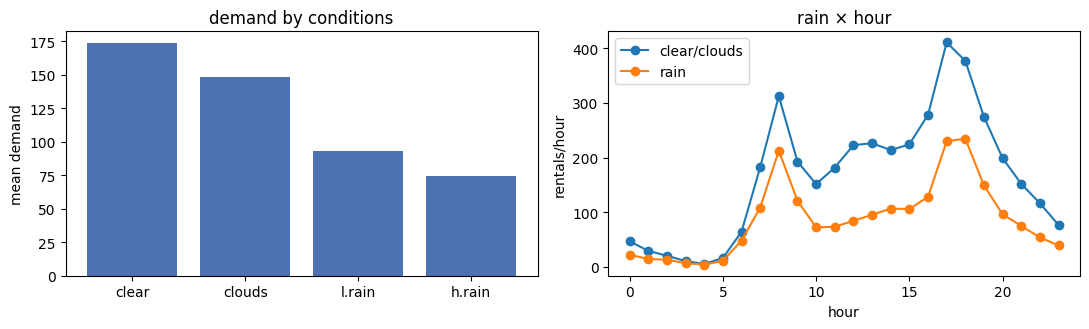

             mean  count
conditions              
0           174.0   7937
1           148.0   3145
2            93.0   1080
3            74.0      3


In [4]:
by_cond = train.groupby("conditions")["total"].agg(["mean", "count"])
prof = (train.assign(rain=(train["conditions"] >= 2).astype(int))
        .groupby(["rain", "hour"])["total"].mean().unstack("rain"))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].bar(by_cond.index, by_cond["mean"], color="#4c72b0")
ax[0].set_xticks([0, 1, 2, 3]); ax[0].set_xticklabels(["clear", "clouds", "l.rain", "h.rain"])
ax[0].set_ylabel("mean demand"); ax[0].set_title("demand by conditions")
ax[1].plot(prof.index, prof[0], marker="o", label="clear/clouds")
ax[1].plot(prof.index, prof[1], marker="o", label="rain")
ax[1].set_xlabel("hour"); ax[1].set_ylabel("rentals/hour"); ax[1].set_title("rain × hour"); ax[1].legend()
plt.tight_layout(); plt.show()
print(by_cond.round(0).to_string())

### Observations

- `conditions` has a clear step effect: clear 174 → clouds 148 → light_rain 93 (heavy_rain 74, but only 3 hours — unreliable).
- Rain lowers demand by 30–58%, most during the day (−58% at 13:00). The rush-hour peaks are more resilient (−32% at 8:00, −44% at 17:00): in the rain people still commute but skip leisure trips. This is a real `weather × hour` interaction.
- But on top of hour and season the gain is small: ablation #2 in [eda_and_modeling](eda_and_modeling.ipynb) added only +0.002 R². Rain is correlated with time, which the model already captures.

## Conclusions

---

- **`perceived_temperature_c` — corr 0.99 with `temperature_c`**, looks redundant. But ablation [#5](eda_and_modeling.ipynb) said otherwise: **we keep it**. Removing it drops HGB R² from 0.892 to 0.879; the ~1% where the two differ (a wind/humidity correction) carries signal. The test decided, not the correlation.
- **Temperature and demand are almost linearly related** (rise, slight saturation, no reversal) — the baseline already captures this, so there is no big gain from temperature.
- **Precipitation really lowers demand** (−30…−58%, stronger during the day), and there is a `rain × hour` interaction. But `conditions` is correlated with time, so on top of hour it adds little (ablation #2).
- Humidity is a weak negative, wind almost zero.

**For the model (arguments of different strength):**
- `temperature_c` + `perceived_temperature_c` — kept **confidently**, by the test: despite corr 0.99, removing perceived drops R² 0.892 → 0.879 (#5).
- `conditions` (and `rain × hour`) — kept **with reservations**: the effect is real and interpretable, but on top of hour/season it adds only +0.002 R² (#2). We take it as nearly free for the tree, not as a strong feature.
- `humidity` — weak negative, `windspeed_kmh` — almost zero: we keep them, no harm.